In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency


In [114]:
df = pd.read_csv('../data/online_shoppers_intention.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

In [115]:
# Check the target variable's class balance
df['Revenue'].value_counts(normalize=True)

Revenue
False    0.845255
True     0.154745
Name: proportion, dtype: float64

Only 15% of sessions ended in a purchase, meaning there'll be a need for a stratified train/test split when modeling, with class_weight='balanced', and metrics beyond accuracy will need to be evaluated.

In [116]:
# Check for duplicates
df.duplicated().sum()

np.int64(125)

There are 125 duplicates in the dataset, which need to be investigated before a decision on method of handling.

In [117]:
# Check if the duplicates have a class imbalance
df[df.duplicated(keep=False)]['Revenue'].value_counts(normalize=True)

Revenue
False    1.0
Name: proportion, dtype: float64

All 125 duplicates are for sessions that did not end in a purchase. Non-purchase sessions are likely to involve less eventful and less varied data such as number of administrative pages visited, if a user is quick to start and end a session without exploring the site.

In [118]:
# Look at the duplicated rows
df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(25)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
8247,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,1,Returning_Visitor,True,False
10751,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,1,Returning_Visitor,True,False
11658,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,1,Returning_Visitor,True,False
8882,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,2,New_Visitor,False,False
11934,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,2,New_Visitor,False,False
11110,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,3,Returning_Visitor,False,False
12159,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,3,Returning_Visitor,False,False
10341,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,4,1,Returning_Visitor,True,False
11801,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,4,1,Returning_Visitor,True,False
11938,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,4,1,Returning_Visitor,True,False


Glancing at the data, there are no specific, unlikely values repeated across duplicated rows that indicate a problem with data collection. There *is* however a trend among the duplicate rows that the session only includes one product page visited, with 0 administrative and informational page visits, suggesting a legitimate, commonly repeated trend of a user seeing the product page and leaving the website without further browsing.  With that pattern, an assumption can be made that the rows with the exact same values may still be distinct user sessions that exhibit similar behavior of entering and then leaving the website shortly after.

In [119]:
# A more thorough check for oddly specific, duplicated values.
dup_rows = df[df.duplicated(keep=False)]
dup_groups = dup_rows.groupby(list(df.columns)).size().reset_index(name='count') # grouped by all columns being exactly the same
dup_groups = dup_groups.sort_values('count', ascending=False)
dup_groups.head(25)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue,count
26,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,2,2,1,1,Returning_Visitor,False,False,14
36,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,3,2,3,1,Returning_Visitor,False,False,7
44,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,May,2,2,1,3,Returning_Visitor,False,False,7
38,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,May,1,1,1,3,Returning_Visitor,False,False,6
13,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,8,13,9,20,Other,False,False,5
34,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,3,2,1,1,Returning_Visitor,False,False,4
41,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,May,1,1,4,3,Returning_Visitor,False,False,4
60,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Nov,2,2,1,1,Returning_Visitor,False,False,4
0,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,1,Returning_Visitor,True,False,3
3,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,4,1,Returning_Visitor,True,False,3


A majority of the duplicate sessions share the pattern of a user entering and leaving the website, leading to default bounce rate, exit rate, and page value metrics, visiting 0 administrative and information pages, and not making a purchase. The duplicate sessions are believable, with no unrealistic values that would indicate the same same user's session showing up twice.

In [120]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [121]:
# Check bounce rate value if no pages were visited
# Are there sessions where no pages were visited?

df_check = df[df['Administrative'] + df['Informational'] + df['ProductRelated'] == 0]
df_check

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
2683,0,0.0,0,0.0,0,0.0,0.20,0.200000,0.0,0.0,May,3,2,3,18,Returning_Visitor,True,False
3187,0,0.0,0,0.0,0,0.0,0.20,0.200000,0.0,0.0,May,2,2,8,3,Returning_Visitor,False,False
5557,0,0.0,0,0.0,0,0.0,0.20,0.200000,0.0,0.0,Nov,1,1,9,3,Returning_Visitor,False,False
5800,0,0.0,0,0.0,0,0.0,0.18,0.181818,0.0,0.0,June,2,2,7,6,Returning_Visitor,False,False
8052,0,0.0,0,0.0,0,0.0,0.20,0.200000,0.0,0.0,Nov,1,1,9,2,Returning_Visitor,False,False
11865,0,0.0,0,0.0,0,0.0,0.20,0.200000,0.0,0.0,Nov,1,1,8,8,Returning_Visitor,False,False


In [122]:
df_check.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,6.0,6.0,6.0,6.0,6.0,6.0,6.000000,6.000000,6.0,6.0,6.000000,6.000000,6.000000,6.000000
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.196667,0.196970,0.0,0.0,1.666667,1.500000,7.333333,6.666667
std,0.0,0.0,0.0,0.0,0.0,0.0,0.008165,0.007423,0.0,0.0,0.816497,0.547723,2.250926,5.988879
min,0.0,0.0,0.0,0.0,0.0,0.0,0.180000,0.181818,0.0,0.0,1.000000,1.000000,3.000000,2.000000
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.200000,0.200000,0.0,0.0,1.000000,1.000000,7.250000,3.000000
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.200000,0.200000,0.0,0.0,1.500000,1.500000,8.000000,4.500000
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.200000,0.200000,0.0,0.0,2.000000,2.000000,8.750000,7.500000
max,0.0,0.0,0.0,0.0,0.0,0.0,0.200000,0.200000,0.0,0.0,3.000000,2.000000,9.000000,18.000000


In [123]:
df_check.shape

(6, 18)

There are only 6 rows where the 3 different pages have combined visits of 0. For those pages the mean bounce and exit rates are ~0.19, and the median is 0.20 for both.

In [124]:
# VisitorType is a string
df['VisitorType'].unique()

<StringArray>
['Returning_Visitor', 'New_Visitor', 'Other']
Length: 3, dtype: str

In [125]:
df['VisitorType'].value_counts()

VisitorType
Returning_Visitor    10551
New_Visitor           1694
Other                   85
Name: count, dtype: int64

In [126]:
pct = df[df['Revenue'] == True]['VisitorType'].value_counts(normalize=True) * 100
print(pct)

VisitorType
Returning_Visitor    77.044025
New_Visitor          22.117400
Other                 0.838574
Name: proportion, dtype: float64


Out of all sessions for which a purchase was made, the type of visitor a returning customer. 

Make a feature 'is_returning_visitor'

In [127]:
df.shape

(12330, 18)

In [128]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [129]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


For page durations - units (seconds vs minutes) were not specified in the metadata. An intuitive guess would be that the duration is represented in seconds, as half of the sessions included a duration of 598 for a product related page, which, if representing seconds, is 10 minutes- and for 75% of product page visits- ~1464 seconds (~24 minutes) or less per session. However whether duration for pages is indeed in seconds cannot be concretely confirmed at this time.

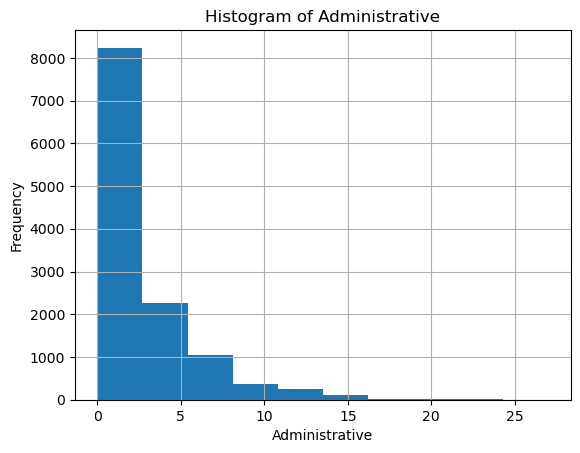

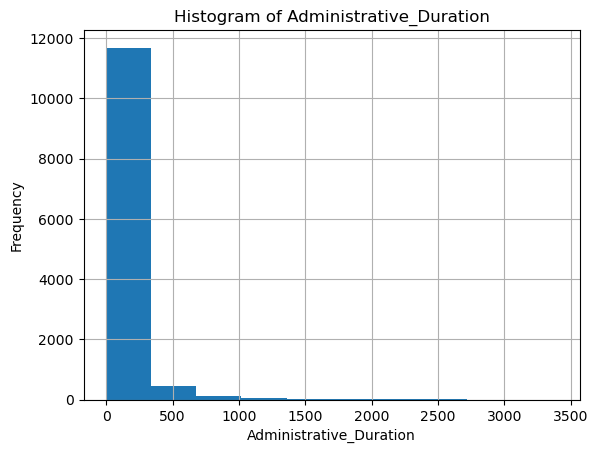

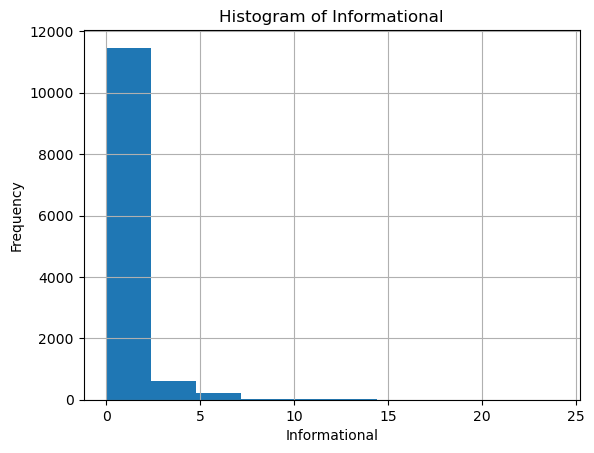

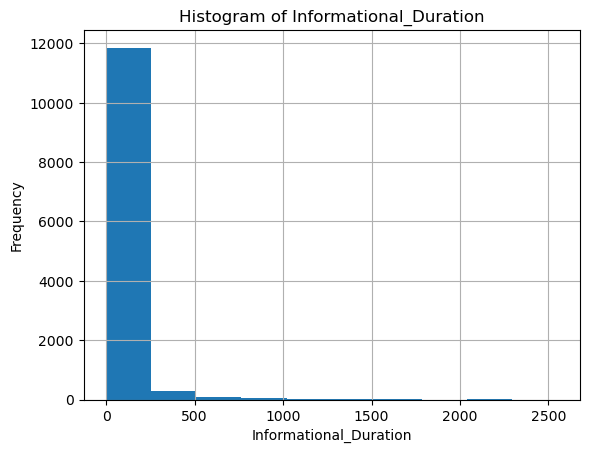

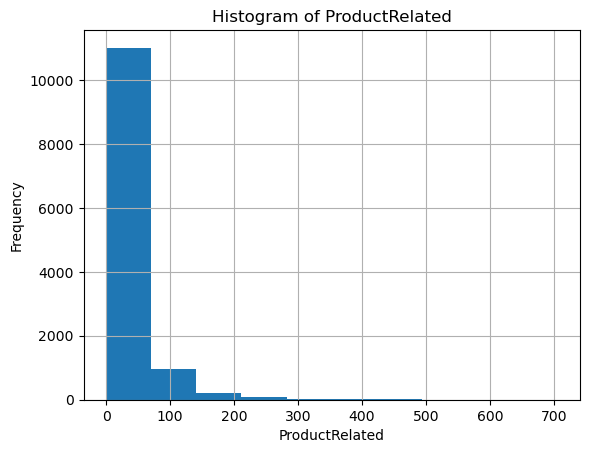

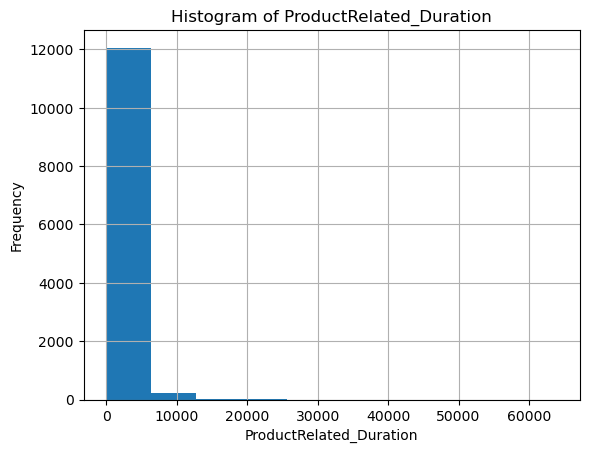

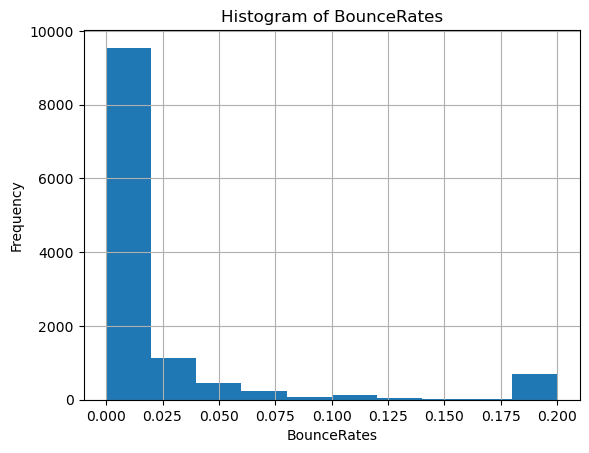

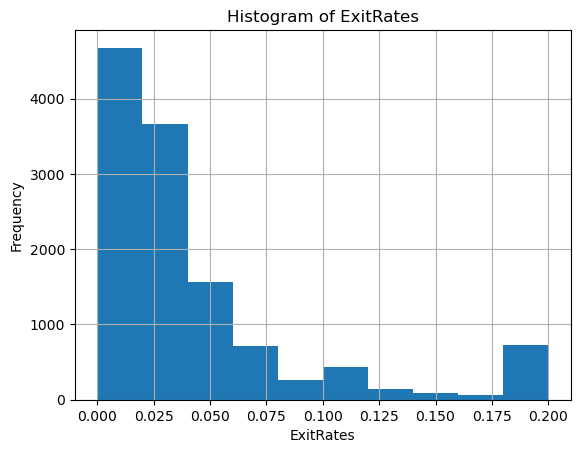

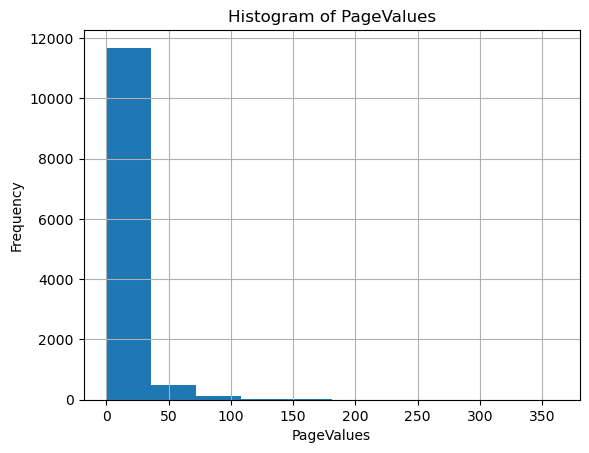

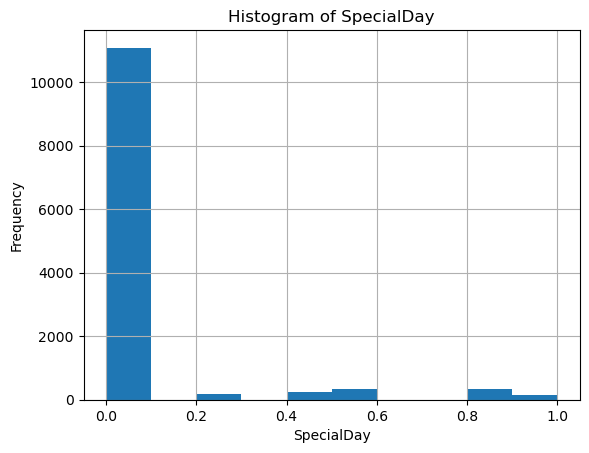

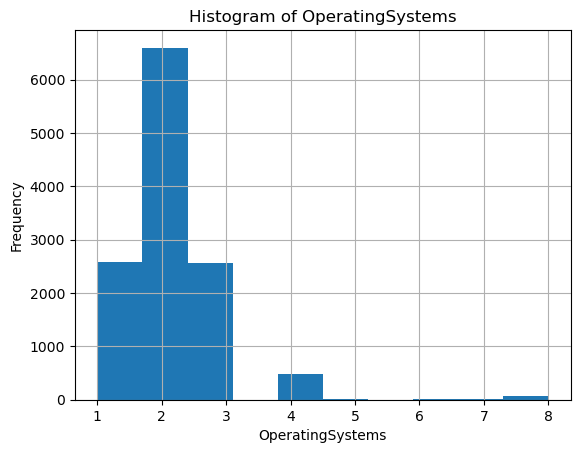

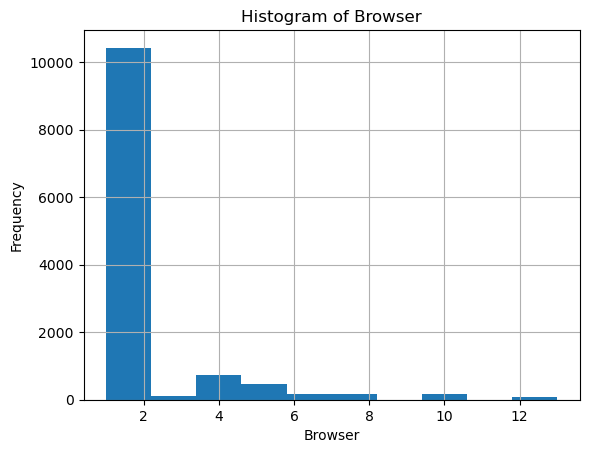

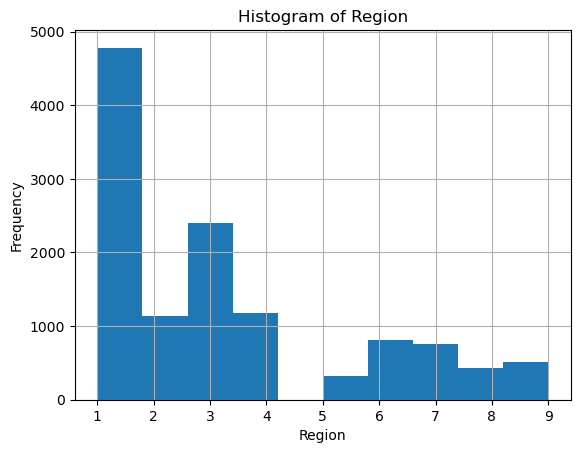

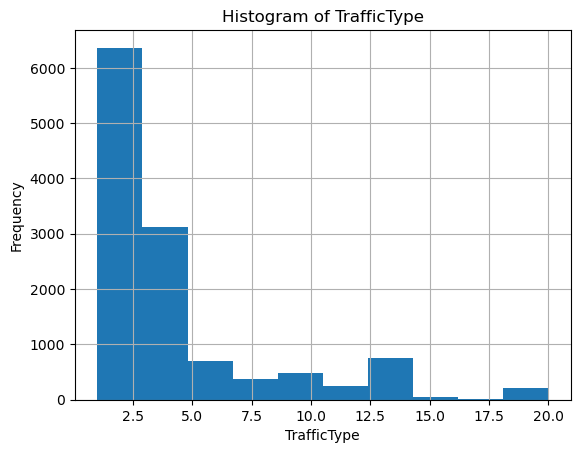

In [130]:
for c in df:
    if c in df.describe():
        plt.figure()
        df[c].hist()
        plt.title(f"Histogram of {c}")
        plt.xlabel(c)
        plt.ylabel("Frequency")

ProductRelated_Duration has an extreme max value of 63973.522230 - assuming the value is in seconds, product page browsing lasted ~18 hours. This could be due to leaving the page open, but may cause problems for our model's coefficients.

In [131]:
# Check all outliers for ProductRelated_Duration
q1 = df['ProductRelated_Duration'].quantile(0.25)
q3 = df['ProductRelated_Duration'].quantile(0.75)
IQR = q3 - q1

lower_boundary = q1 - 1.5 * IQR
upper_boundary = q3 + 1.5 * IQR

outliers = df[(df['ProductRelated_Duration'] < lower_boundary) | (df['ProductRelated_Duration'] > upper_boundary)]
outliers.shape

(961, 18)

In [132]:
# Check how many of these sessions led to a purchase
outliers['Revenue'].value_counts(normalize=True)

Revenue
False    0.699272
True     0.300728
Name: proportion, dtype: float64

While 15% of all original sessions ended with a purchase, abnormaly long sessions identified in the 961 outliers showed an increased rate of a purchase being made - at 30%.

Adding onto that, removing these 961 outliers would reduce a sizable chunk of the data, including hundreds with generated revenue, exasperating the class imbalance even further.

In [133]:
# Investigate the highest duration outliers
outliers = outliers.sort_values('ProductRelated_Duration', ascending=False).reset_index()
outliers

,index,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,8071,5,3398.750000,6,2549.375000,449,63973.522230,0.000764,0.027701,0.000000,0.0,Dec,2,2,1,2,Returning_Visitor,False,False
1,5152,17,2629.253968,24,2050.433333,705,43171.233380,0.004851,0.015431,0.763829,0.0,May,2,2,1,14,Returning_Visitor,True,False
2,9238,15,2657.318056,13,1949.166667,343,29970.465970,0.005316,0.028971,0.000000,0.0,Dec,2,2,1,2,Returning_Visitor,False,False
3,8784,20,1307.675000,3,132.666667,517,27009.859430,0.004385,0.014594,8.403164,0.0,Nov,1,1,1,2,Returning_Visitor,False,True
4,8308,27,853.735949,2,126.500000,584,24844.156200,0.002099,0.009347,4.511100,0.0,Nov,2,4,3,8,Returning_Visitor,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
956,4162,7,105.750000,0,0.000000,124,3394.130159,0.001587,0.012919,5.921482,0.0,May,2,2,3,11,Returning_Visitor,True,False
957,3114,2,7.000000,1,0.000000,79,3393.903571,0.017762,0.040310,0.000000,1.0,May,2,2,1,5,Returning_Visitor,True,False
958,9773,2,20.000000,0,0.000000,66,3391.685880,0.028955,0.038336,0.000000,0.0,Dec,3,2,8,1,Returning_Visitor,False,False
959,7800,0,0.000000,0,0.000000,41,3389.800000,0.032479,0.050194,0.000000,0.0,Sep,2,4,3,1,Returning_Visitor,False,False


In [187]:
outliers.head(20)

,index,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,8071,5,3398.750000,6,2549.375000,449,63973.52223,0.000764,0.027701,0.000000,0.0,Dec,2,2,1,2,Returning_Visitor,False,False
1,5152,17,2629.253968,24,2050.433333,705,43171.23338,0.004851,0.015431,0.763829,0.0,May,2,2,1,14,Returning_Visitor,True,False
2,9238,15,2657.318056,13,1949.166667,343,29970.46597,0.005316,0.028971,0.000000,0.0,Dec,2,2,1,2,Returning_Visitor,False,False
3,8784,20,1307.675000,3,132.666667,517,27009.85943,0.004385,0.014594,8.403164,0.0,Nov,1,1,1,2,Returning_Visitor,False,True
4,8308,27,853.735949,2,126.500000,584,24844.15620,0.002099,0.009347,4.511100,0.0,Nov,2,4,3,8,Returning_Visitor,False,False
5,7662,10,1251.200000,7,250.000000,414,23888.81000,0.009900,0.027062,1.033757,0.0,Sep,2,2,4,13,Returning_Visitor,False,False
6,6684,20,199.456273,7,299.033333,686,23342.08205,0.009853,0.022771,0.150650,0.0,Aug,2,2,1,1,Returning_Visitor,False,False
7,6165,10,2407.423810,3,434.300000,486,23050.10414,0.000324,0.011249,0.000000,0.0,Jul,2,2,1,3,Returning_Visitor,False,False
8,5916,12,245.733333,4,1511.700000,439,21857.04648,0.003589,0.012498,11.439233,0.0,Sep,2,2,1,13,Returning_Visitor,False,False
9,8972,11,631.416667,5,1037.150000,501,21672.24425,0.003965,0.014292,9.131387,0.0,Nov,2,2,1,2,Returning_Visitor,False,True


These extreme values do not appear only in one or two rows- to avoid data loss, I'll cap impossible active browsing sessions - which are the ones we aim to keep. A session continuing in a product page due to an open tab prevents us from accurately interpreting what the coefficient in a logistical regression represents - an 'x' increase in duration leads to a'y' increase in probability of a purchase.

Make a new column with the capped variable and then compare model performance with and without capping.

In [134]:
df['ProductRelated_Duration'].describe()

count    12330.000000
mean      1194.746220
std       1913.669288
min          0.000000
25%        184.137500
50%        598.936905
75%       1464.157214
max      63973.522230
Name: ProductRelated_Duration, dtype: float64

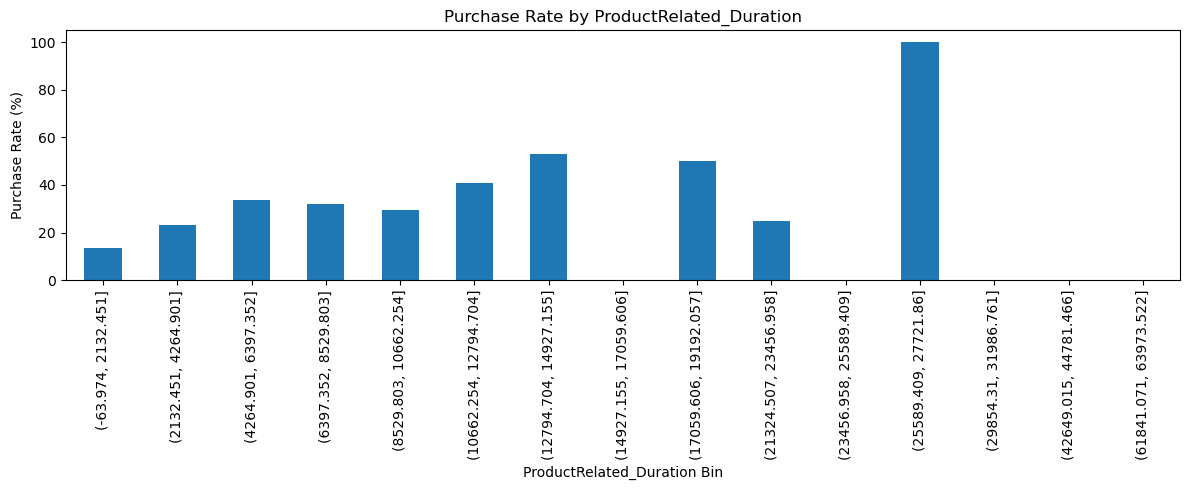

duration_bin
(-63.974, 2132.451]       10394
(2132.451, 4264.901]       1308
(4264.901, 6397.352]        358
(6397.352, 8529.803]        134
(8529.803, 10662.254]        68
(10662.254, 12794.704]       32
(12794.704, 14927.155]       17
(14927.155, 17059.606]        5
(17059.606, 19192.057]        4
(21324.507, 23456.958]        4
(23456.958, 25589.409]        2
(25589.409, 27721.86]         1
(29854.31, 31986.761]         1
(42649.015, 44781.466]        1
(61841.071, 63973.522]        1
dtype: int64

In [135]:
# Decide the cap threshold by identifying the product browsing duration at which purchasing rate is not impacted.
df['duration_bin'] = pd.cut(df['ProductRelated_Duration'], bins=30)

bin_purchase_rate = df.groupby('duration_bin')['Revenue'].mean() * 100
bin_counts = df.groupby('duration_bin').size()

fig, ax = plt.subplots(figsize=(12, 5))
bin_purchase_rate.plot(kind='bar', ax=ax)
ax.set_ylabel('Purchase Rate (%)')
ax.set_xlabel('ProductRelated_Duration Bin')
plt.xticks(rotation=90)
plt.title('Purchase Rate by ProductRelated_Duration')
plt.tight_layout()
plt.show()
bin_counts


Bin 12794.704 - 14927.155 equals a range of about 3.55 - 4.15 hours, with 17 sessions. 
Bins after this one only have 1-5 sessions, providing too little data to draw conclusions from.
17 is still too small of a session sample amount to reliably cap duration at this bin's maximum. 
Most sessions land in the first bin, then the second, so this chart does not reliably show where rate plateaus. I'll have to make bins where each has a comparable size of sessions to draw more reliable conclusions.

In [136]:
df['duration_qbin'] = pd.qcut(df['ProductRelated_Duration'], q=15)
qbin_purchase_rate = df.groupby('duration_qbin')['Revenue'].mean() * 100
bin_counts = df.groupby('duration_qbin').size()
bin_counts

duration_qbin
(-0.001, 8.0]            825
(8.0, 63.658]            819
(63.658, 129.0]          824
(129.0, 203.399]         820
(203.399, 293.472]       822
(293.472, 402.117]       822
(402.117, 529.314]       822
(529.314, 675.911]       822
(675.911, 852.0]         823
(852.0, 1087.795]        821
(1087.795, 1375.831]     822
(1375.831, 1775.929]     822
(1775.929, 2408.611]     822
(2408.611, 3708.385]     822
(3708.385, 63973.522]    822
dtype: int64

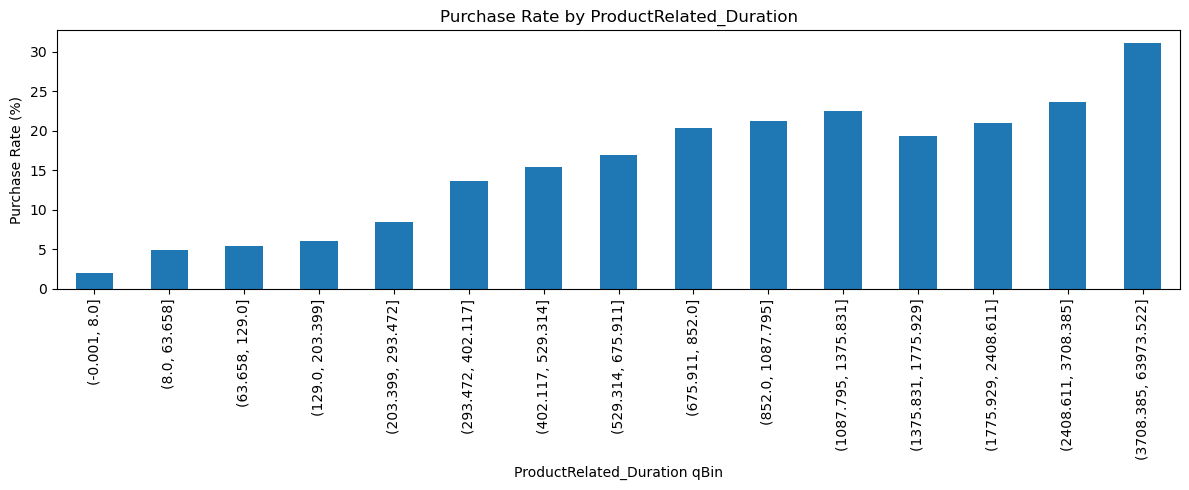

duration_qbin
(-0.001, 8.0]            825
(8.0, 63.658]            819
(63.658, 129.0]          824
(129.0, 203.399]         820
(203.399, 293.472]       822
(293.472, 402.117]       822
(402.117, 529.314]       822
(529.314, 675.911]       822
(675.911, 852.0]         823
(852.0, 1087.795]        821
(1087.795, 1375.831]     822
(1375.831, 1775.929]     822
(1775.929, 2408.611]     822
(2408.611, 3708.385]     822
(3708.385, 63973.522]    822
dtype: int64

In [137]:
fig, ax = plt.subplots(figsize=(12, 5))
qbin_purchase_rate.plot(kind='bar', ax=ax)
ax.set_ylabel('Purchase Rate (%)')
ax.set_xlabel('ProductRelated_Duration qBin')
plt.xticks(rotation=90)
plt.title('Purchase Rate by ProductRelated_Duration')
plt.tight_layout()
plt.show()
bin_counts

In [138]:
df['mean_product_duration'] = df['ProductRelated_Duration'] / df['ProductRelated']
df['mean_product_duration'].describe()

count    12292.000000
mean        37.750032
std         44.788059
min          0.000000
25%         17.731942
50%         28.978266
75%         45.123375
max       1411.000000
Name: mean_product_duration, dtype: float64

In [139]:
df['duration_qbin'] = pd.qcut(df['mean_product_duration'], q=15)
qbin_purchase_rate = df.groupby('duration_qbin')['Revenue'].mean() * 100
bin_counts = df.groupby('duration_qbin').size()
bin_counts

duration_qbin
(-0.001, 4.0]       821
(4.0, 11.515]       818
(11.515, 15.376]    820
(15.376, 18.449]    819
(18.449, 21.445]    820
(21.445, 24.298]    819
(24.298, 27.372]    819
(27.372, 30.575]    820
(30.575, 34.131]    819
(34.131, 38.446]    820
(38.446, 43.597]    819
(43.597, 50.8]      819
(50.8, 61.811]      820
(61.811, 84.413]    819
(84.413, 1411.0]    820
dtype: int64

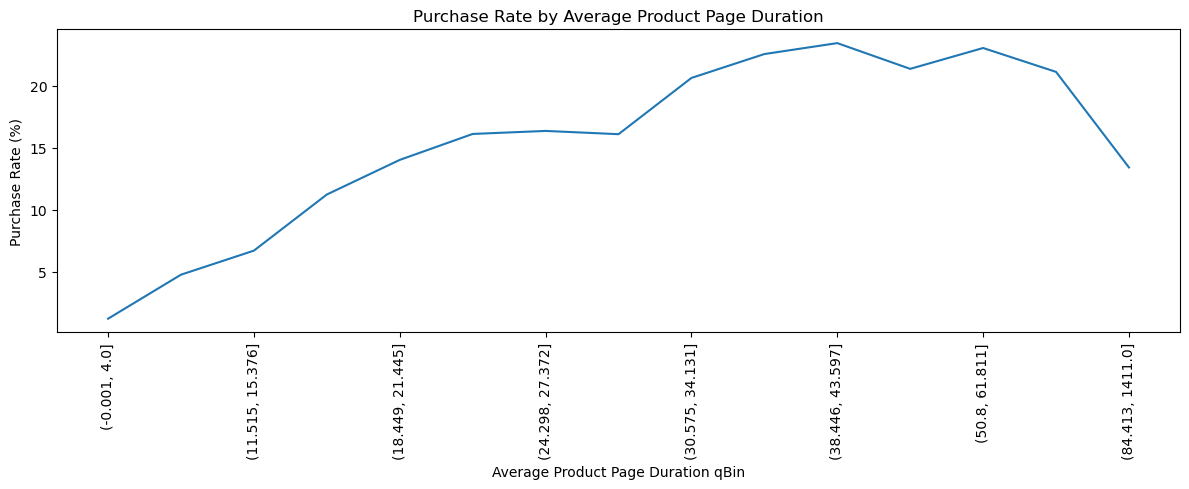

duration_qbin
(-0.001, 4.0]       821
(4.0, 11.515]       818
(11.515, 15.376]    820
(15.376, 18.449]    819
(18.449, 21.445]    820
(21.445, 24.298]    819
(24.298, 27.372]    819
(27.372, 30.575]    820
(30.575, 34.131]    819
(34.131, 38.446]    820
(38.446, 43.597]    819
(43.597, 50.8]      819
(50.8, 61.811]      820
(61.811, 84.413]    819
(84.413, 1411.0]    820
dtype: int64

In [140]:
fig, ax = plt.subplots(figsize=(12, 5))
qbin_purchase_rate.plot(kind='line', ax=ax)
ax.set_ylabel('Purchase Rate (%)')
ax.set_xlabel('Average Product Page Duration qBin')
plt.xticks(rotation=90)
plt.title('Purchase Rate by Average Product Page Duration')
plt.tight_layout()
plt.show()
bin_counts

Purchase rate plateaus after 38 seconds, with a downward trend after ~62 seconds, suggesting that beyond that point, increased duration does not improve purchase outcomes.

In [141]:
# Investigate the last bin, all which are outliers, and see the percentage that generated revenue to identify if they may show signal.
last_bin = df[df['duration_qbin'] == pd.Interval(84.413, 1411.0)]

last_bin_p_rate = last_bin['Revenue'].mean() * 100
last_bin_p_rate

np.float64(13.414634146341465)

The last bin shows a similar % of sessions leading to a purchase as the overall dataset (at 15%)

In [142]:
# Investigate the distribution of the last bin
last_bin['mean_product_duration'].describe()

count     820.000000
mean      145.591249
std       113.030090
min        84.428571
25%        95.919034
50%       113.362519
75%       147.916667
max      1411.000000
Name: mean_product_duration, dtype: float64

The max value amongst the outliers has a mean average per-page view of 1411 seconds - which is nearly 10x higher than 75% of the other sessions. This can be treated as an abnormal session - numbering few, and unexplained.

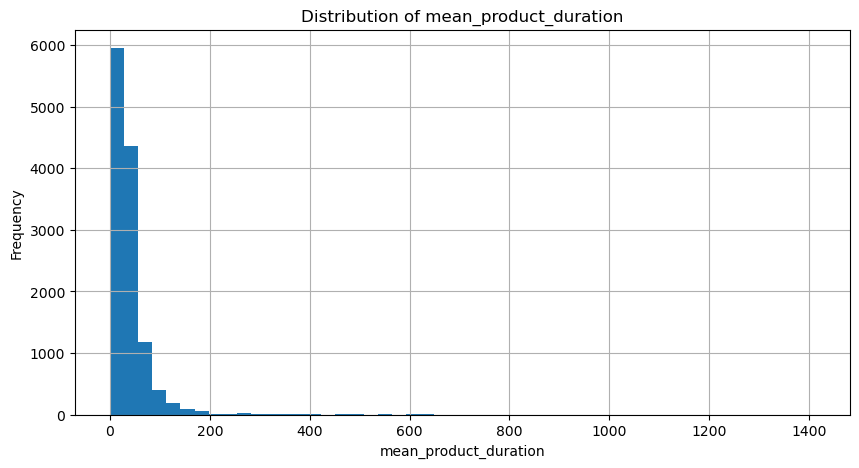

In [189]:
df['mean_product_duration'].hist(bins=50, figsize=(10,5))
plt.xlabel('mean_product_duration')
plt.ylabel('Frequency')
plt.title('Distribution of mean_product_duration')
plt.show()

In [188]:
last_bin_rows = last_bin.sort_values('mean_product_duration', ascending=False).reset_index()
last_bin_rows.head(30)

,index,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,...,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue,duration_bin,duration_qbin,mean_product_duration
0,536,0,0.00,1,1411.0,1,1411.000000,0.000000,0.100000,0.000000,...,2,2,1,2,Returning_Visitor,False,False,"(-63.974, 2132.451]","(84.413, 1411.0]",1411.000000
1,4583,0,0.00,0,0.0,1,1364.000000,0.000000,0.100000,0.000000,...,3,2,4,4,Returning_Visitor,False,False,"(-63.974, 2132.451]","(84.413, 1411.0]",1364.000000
2,6333,0,0.00,0,0.0,1,1195.800000,0.000000,0.000000,0.000000,...,2,2,7,13,Returning_Visitor,False,False,"(-63.974, 2132.451]","(84.413, 1411.0]",1195.800000
3,11580,0,0.00,0,0.0,2,1787.500000,0.100000,0.150000,0.000000,...,3,2,3,13,Returning_Visitor,False,False,"(-63.974, 2132.451]","(84.413, 1411.0]",893.750000
4,8461,0,0.00,0,0.0,3,2251.280000,0.095833,0.137427,0.000000,...,3,2,1,13,Returning_Visitor,False,False,"(2132.451, 4264.901]","(84.413, 1411.0]",750.426667
5,8426,0,0.00,0,0.0,1,695.500000,0.000000,0.100000,0.000000,...,2,2,4,1,Returning_Visitor,False,False,"(-63.974, 2132.451]","(84.413, 1411.0]",695.500000
6,9671,0,0.00,0,0.0,3,1952.500000,0.066667,0.122222,0.000000,...,1,1,2,1,Returning_Visitor,False,False,"(-63.974, 2132.451]","(84.413, 1411.0]",650.833333
7,2176,0,0.00,0,0.0,1,643.000000,0.133333,0.150000,0.000000,...,2,2,1,5,Returning_Visitor,False,False,"(-63.974, 2132.451]","(84.413, 1411.0]",643.000000
8,488,0,0.00,0,0.0,4,2528.000000,0.000000,0.066667,0.000000,...,2,2,9,1,Returning_Visitor,True,False,"(2132.451, 4264.901]","(84.413, 1411.0]",632.000000
9,3861,0,0.00,0,0.0,1,612.000000,0.000000,0.100000,0.000000,...,1,1,1,3,Returning_Visitor,False,False,"(-63.974, 2132.451]","(84.413, 1411.0]",612.000000


Amongst the last 30 rows of the highest duration data, the 20 sessions averaging the longest duration per product page ended with no purchase, possibly indicated tabbed out, unengaged browsing sessions, averaging 7-24 minutes per product page.

The sessions after the first 20 begin showing purchasing behavior, and average less than 7 minutes per page.

The 20 rows of data will be dropped in order to reduce noise.

In [ ]:
# Perform similar exploration of administrative and informational durations
df['mean_administrative_duration'] = df['Administrative_Duration'] / df['Administrative']
df['mean_administrative_duration'].describe()

count    6562.000000
mean       37.948819
std        57.460324
min         0.000000
25%        13.600000
50%        23.000000
75%        42.000000
max      1566.600000
Name: mean_administrative_duration, dtype: float64

Another type of duration with an extreme max value compared to 75% of the sessions.

In [197]:
outlier_admin_mean_dur = df.sort_values(by='mean_administrative_duration', ascending=False)
outlier_admin_mean_dur.head(30)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Browser,Region,TrafficType,VisitorType,Weekend,Revenue,duration_bin,duration_qbin,mean_product_duration,mean_administrative_duration
5942,1,1566.600000,0,0.000000,34,2256.749540,0.000000,0.000250,0.000000,0.0,...,2,3,2,Returning_Visitor,False,False,"(2132.451, 4264.901]","(61.811, 84.413]",66.374986,1566.600000
224,1,993.000000,0,0.000000,28,1529.304670,0.001481,0.009150,0.000000,0.0,...,2,4,2,Returning_Visitor,False,False,"(-63.974, 2132.451]","(50.8, 61.811]",54.618024,993.000000
2446,2,1687.500000,0,0.000000,29,3098.033333,0.000000,0.025806,0.000000,0.0,...,4,5,3,Returning_Visitor,False,False,"(2132.451, 4264.901]","(84.413, 1411.0]",106.828736,843.750000
9633,2,1668.500000,4,35.000000,18,1372.975000,0.000000,0.017391,41.646259,0.0,...,2,1,6,Returning_Visitor,False,True,"(-63.974, 2132.451]","(61.811, 84.413]",76.276389,834.250000
1996,1,702.000000,0,0.000000,38,2193.150794,0.012281,0.015614,9.092772,0.0,...,1,2,2,Returning_Visitor,False,True,"(2132.451, 4264.901]","(50.8, 61.811]",57.714495,702.000000
8071,5,3398.750000,6,2549.375000,449,63973.522230,0.000764,0.027701,0.000000,0.0,...,2,1,2,Returning_Visitor,False,False,"(61841.071, 63973.522]","(84.413, 1411.0]",142.480005,679.750000
1336,1,613.666667,0,0.000000,4,957.000000,0.161905,0.096299,0.000000,0.0,...,2,8,10,Returning_Visitor,False,False,"(-63.974, 2132.451]","(84.413, 1411.0]",239.250000,613.666667
1351,2,1223.000000,4,416.000000,21,2755.670940,0.004545,0.027576,0.000000,0.0,...,2,1,2,Returning_Visitor,True,False,"(2132.451, 4264.901]","(84.413, 1411.0]",131.222426,611.500000
5004,2,1172.000000,0,0.000000,24,1244.066667,0.008000,0.028000,0.000000,0.0,...,8,2,6,Returning_Visitor,False,False,"(-63.974, 2132.451]","(50.8, 61.811]",51.836111,586.000000
11344,1,585.500000,0,0.000000,80,3634.141512,0.004321,0.007864,26.411138,0.0,...,2,2,2,Returning_Visitor,False,True,"(2132.451, 4264.901]","(43.597, 50.8]",45.426769,585.500000


Within the sessions with the longest average informational page durations, there are sessions with finalized purchases, and no obvious pattern to indicate tabbed out, inactive sessions. 

## Variables vs Desired Outcome (Revenue)

In the markdowns following the charts and groupby statements, i use median and mean in selective ways - where there are outliers for the max value of a variable, I use median, and I use either when there are no outliers, since the average wont be pulled by outlier values.

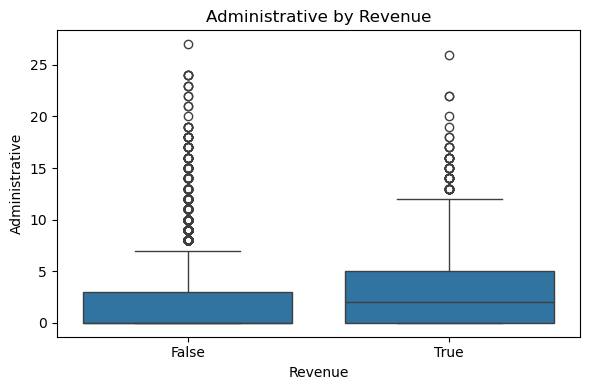

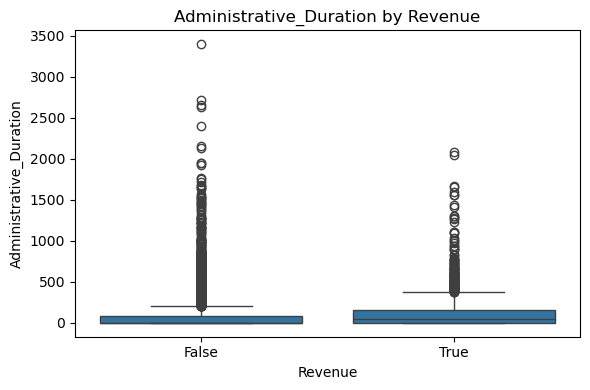

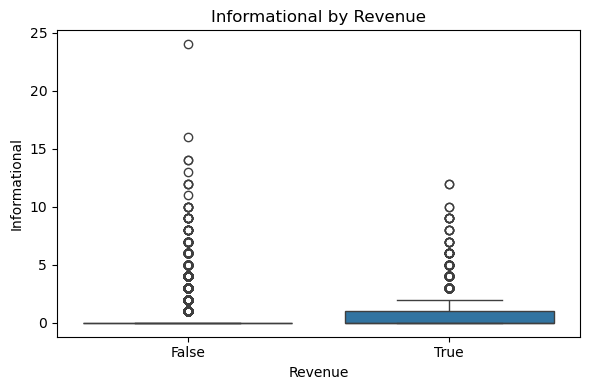

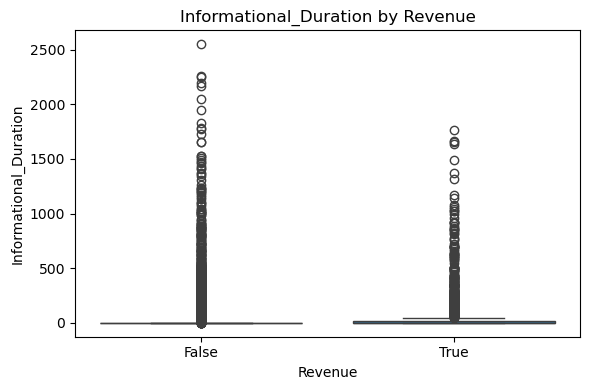

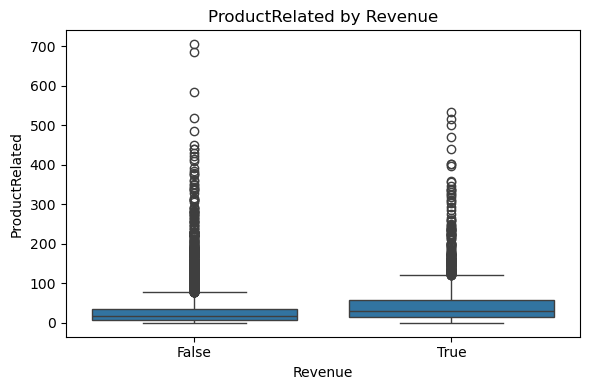

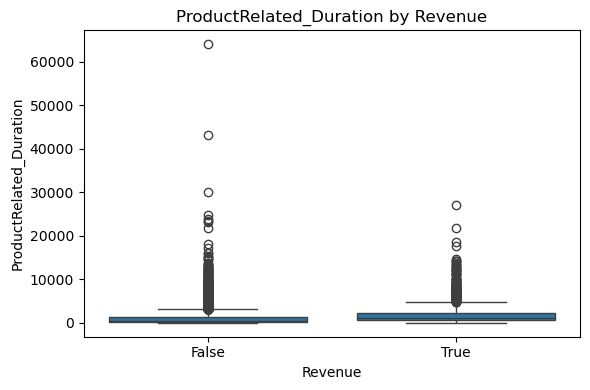

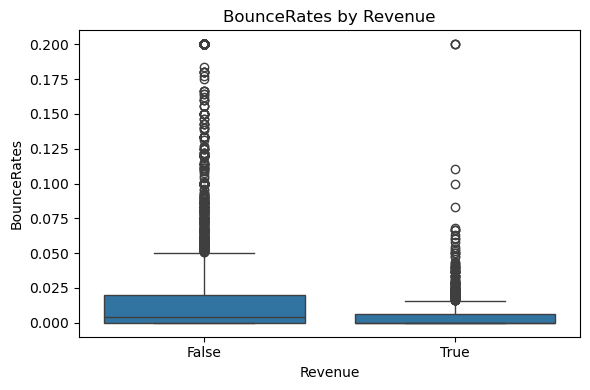

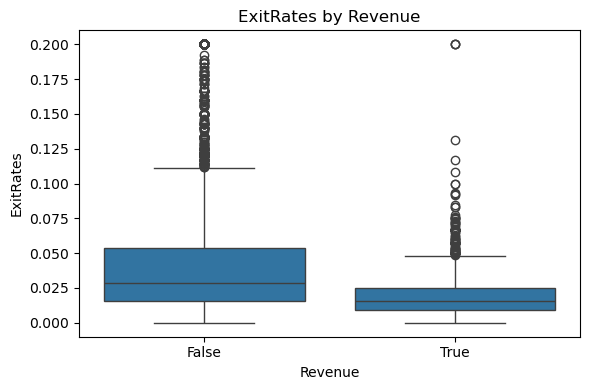

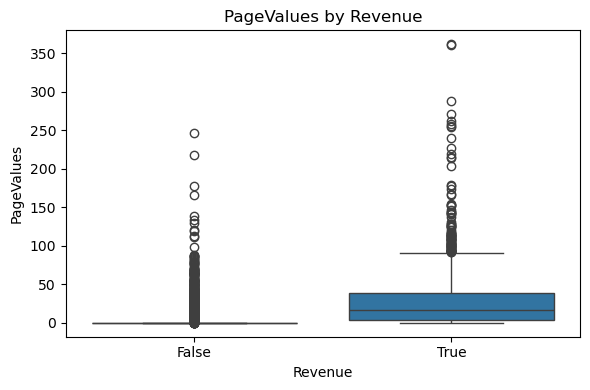

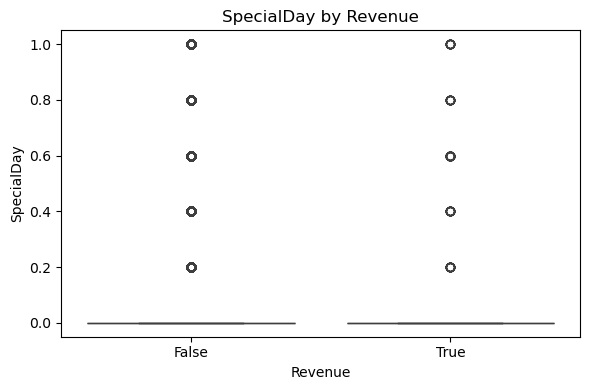

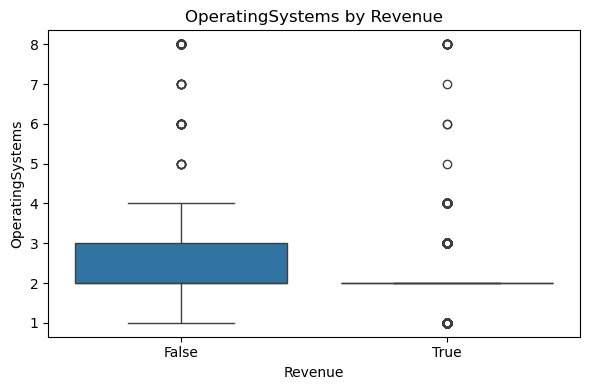

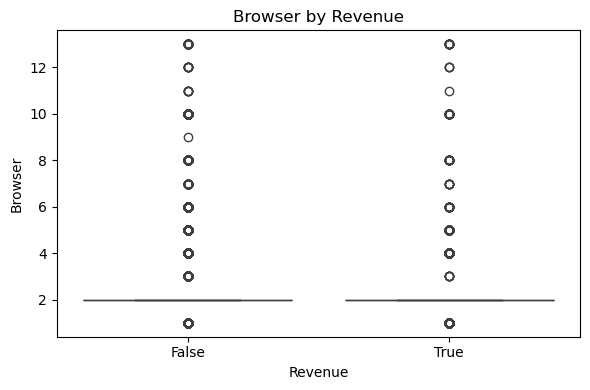

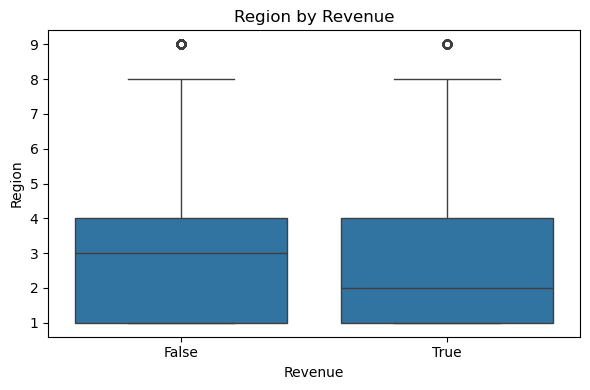

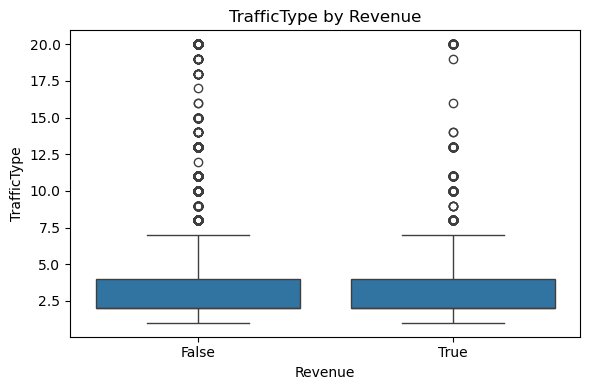

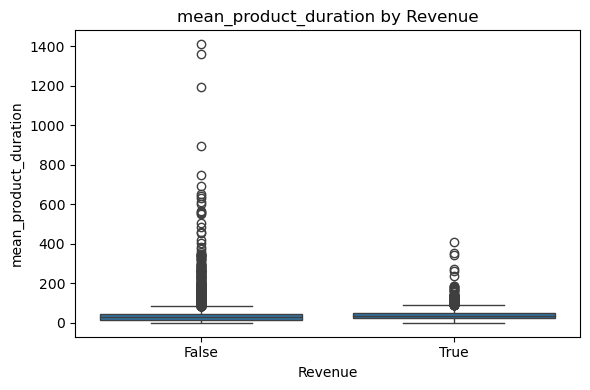

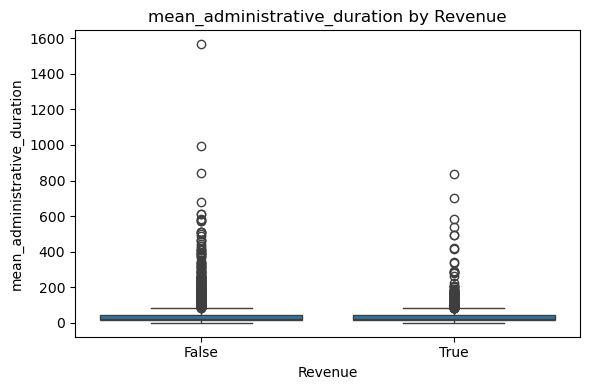

In [146]:
# Preliminary look at numerical variables against the desired outcome variable

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='Revenue', y=col, data=df)
    plt.title(f'{col} by Revenue')
    plt.xlabel('Revenue')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

Multiple variables are heavily right-skewed, meaning they'll need to be handled before being utilized in a logistic regression model, which is sensitive to outliers.

The median number of pages visited for non-purchasers was around 0, while for purchasers it was around 2.5.
The duration for administrative page visits was also higher for purchasers.


In [147]:
df.groupby('Revenue')['Administrative'].describe()

,count,mean,std,min,25%,50%,75%,max
Revenue,,,,,,,,
False,10422.0,2.117732,3.202481,0.0,0.0,0.0,3.0,27.0
True,1908.0,3.393606,3.730527,0.0,0.0,2.0,5.0,26.0


For sessions that did end in a purchase, half of the users visited at least ~2 administrative pages, as opposed to 0 for non-purchase sessions.

In [148]:
df.groupby('Revenue')['Administrative_Duration'].describe()

,count,mean,std,min,25%,50%,75%,max
Revenue,,,,,,,,
False,10422.0,73.740111,171.017970,0.0,0.0,0.000000,83.000000,3398.75
True,1908.0,119.483244,201.114732,0.0,0.0,52.366667,151.083333,2086.75


Pick either Administrative pages or Administrative duration for the logistic regression model - do not use both as they're highly correlated.

Options: Ridge or Lasso regularization for automatic feature selection, or run VIF before and after dropping one of the variables.

Looking at the Informational vs Revenue graph, nearly no one aside from outlier cases, visited informational pages, except for when revenue was earned in a session - there was a percent of people who at least visited one. 

In [149]:
df.groupby('Revenue')['Informational'].describe()

,count,mean,std,min,25%,50%,75%,max
Revenue,,,,,,,,
False,10422.0,0.451833,1.211582,0.0,0.0,0.0,0.0,24.0
True,1908.0,0.786164,1.521176,0.0,0.0,0.0,1.0,12.0


25% of sessions with a purchase made had the user visit at least 1 informational page.

In [150]:
df.groupby('Revenue')['Informational_Duration'].describe()

,count,mean,std,min,25%,50%,75%,max
Revenue,,,,,,,,
False,10422.0,30.236237,133.909306,0.0,0.0,0.0,0.0,2549.375000
True,1908.0,57.611427,171.619131,0.0,0.0,0.0,19.0,1767.666667


Informational page visit duration was at 0 for nearly all sessions with no purchase, while at least 25% of sessions with a purchase spent 19 seconds on a page.

In [151]:
df.groupby('Revenue')['ProductRelated'].describe()

,count,mean,std,min,25%,50%,75%,max
Revenue,,,,,,,,
False,10422.0,28.714642,40.744717,0.0,6.0,16.0,35.0,705.0
True,1908.0,48.210168,58.267365,0.0,15.0,29.0,57.0,534.0


The number of product related pages visited in sessions with generated revenue had a median pages visited nearly nearly 2x higher than for sessions without revenue.

In [152]:
df.groupby('Revenue')['ProductRelated_Duration'].describe()

,count,mean,std,min,25%,50%,75%,max
Revenue,,,,,,,,
False,10422.0,1069.987809,1803.797757,0.0,151.00000,510.19000,1331.816667,63973.52223
True,1908.0,1876.209615,2312.214392,0.0,541.90625,1109.90625,2266.011310,27009.85943


Product related page visit duration had a median visit take more than 2x longer for sessions with generated revenue.

In [153]:
df.groupby('Revenue')['BounceRates'].describe()

,count,mean,std,min,25%,50%,75%,max
Revenue,,,,,,,,
False,10422.0,0.025317,0.051877,0.0,0.0,0.004255,0.020000,0.2
True,1908.0,0.005117,0.012185,0.0,0.0,0.000000,0.006452,0.2


The average bounce rate is nearly 5x higher for sessions in which a purchase was not made.

In [154]:
df.groupby('Revenue')['ExitRates'].describe()

,count,mean,std,min,25%,50%,75%,max
Revenue,,,,,,,,
False,10422.0,0.047378,0.051231,0.0,0.015560,0.028571,0.053846,0.2
True,1908.0,0.019555,0.016463,0.0,0.009521,0.016000,0.025000,0.2


mean exit rates were more than 2x higher for sessions without generated revenue.

In [155]:
df.groupby('Revenue')['PageValues'].describe()

,count,mean,std,min,25%,50%,75%,max
Revenue,,,,,,,,
False,10422.0,1.975998,9.072424,0.0,0.000000,0.000000,0.000000,246.758590
True,1908.0,27.264518,35.191954,0.0,3.641144,16.758134,38.897742,361.763742


That being said, there are significant differences in metrics- the median page value for sessions with a purchase is 16, compared to 0 for non-purchase sessions. At least 75% of revenue generating sessions had non-zero page values, while at least 75% of non revenue generating sessions had page values of exactly *zero*.

PageValues are derived from the revenue pages generate, so intuitively, pages that have high page values will likely lead to more generated revenue, which means they'll show up in our sessions with generated revenue more often. Page values will be a good predictive variable for the model.

In [156]:
df.groupby('Revenue')['SpecialDay'].describe()

,count,mean,std,min,25%,50%,75%,max
Revenue,,,,,,,,
False,10422.0,0.068432,0.209054,0.0,0.0,0.0,0.0,1.0
True,1908.0,0.023166,0.123521,0.0,0.0,0.0,0.0,1.0


For sessions where a purchase was made, the average distance to a special day was almost 3 times closer.

In [157]:
pd.crosstab(df['OperatingSystems'],df['Revenue'])

Revenue,False,True
OperatingSystems,,
1,2206,379
2,5446,1155
3,2287,268
4,393,85
5,5,1
6,17,2
7,6,1
8,62,17


OperatingSystems will need to be one hot encoded for the model. 

The most common operating systems used were 1-4, with 1-3 dominating in total usage. OS systems 5, 6, 7, and 8 have too little data to reliably predict off of in a model. They will be kept due to containing other useful variable information, but the OS for those three will be engineered as "other_OS". 

In [158]:
df_OS = df.groupby('OperatingSystems')['Revenue'].mean() * 100
df_OS

OperatingSystems
1    14.661509
2    17.497349
3    10.489237
4    17.782427
5    16.666667
6    10.526316
7    14.285714
8    21.518987
Name: Revenue, dtype: float64

The average number of revenue generating sessions by OS vary between the first 4, most popular systems, with a difference of up to 7 points.

In [159]:
contingency = pd.crosstab(df['OperatingSystems'], df['Revenue'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(p)

1.4160941129614401e-13


In [160]:
def cramers_v(chi2, contingency):
    n = contingency.sum().sum()
    r, k = contingency.shape
    return np.sqrt(chi2 / (n * (min(r,k) - 1)))

v = cramers_v(chi2, contingency)
print(v)

0.07800589336761586


The p value shows that OperatingSystems and Revenue have a statistically significant association, but Cramer's V value shows that the relationship is weak, being under 0.1. This feature will be dropped.

In [161]:
browser_counts = df['Browser'].value_counts()
browser_counts

Browser
2     7961
1     2462
4      736
5      467
6      174
10     163
8      135
3      105
13      61
7       49
12      10
11       6
9        1
Name: count, dtype: int64

The most popular browsers are 1,2,4 and 5, with 2 making up a majority (~65%) of all sessions.

Similarly to the OS variable, browsers 13, 7, 12, 11, and 9 have too little data (chosen here arbitrarily as being under 100 records) to be included in training - high percentage of average occurrences that revenue is generated, when total usage of the browsers is low, can cause over inflated predictions. These browsers should go under an engineered 'other_browser' feature.

In [162]:
df.groupby('Browser')['Revenue'].mean() * 100

Browser
1     14.825345
2     15.362392
3      4.761905
4     17.663043
5     18.415418
6     11.494253
7     12.244898
8     15.555556
9      0.000000
10    19.631902
11    16.666667
12    30.000000
13    26.229508
Name: Revenue, dtype: float64

Besides the least used browsers in the dataset, the average purchase frequency between browsers is not obviously different at a glance.

In [163]:
# Run a statistical test for association
contingency = pd.crosstab(df['Browser'], df['Revenue'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(p)

0.00608754317955109


A p value less than 0.05 suggests Revenue is associated with the Browser variable, and differences are unlikely due to random chance.

In [164]:
# Check p value on browsers with records over 100 to see if browsers with less data influenced the p score.
min_count = 100
filtered_browsers = browser_counts[browser_counts > min_count].index

df_filtered = df[df['Browser'].isin(filtered_browsers)]

contingency_filtered = pd.crosstab(df_filtered['Browser'], df_filtered['Revenue'])
chi2, p, dof, expected = chi2_contingency(contingency_filtered)

print(p)

0.005239314772361984


The p value is even smaller, indicating Browser does have a non-random association with Revenue.

In [165]:
def cramers_v(chi2, contingency):
    n = contingency.sum().sum()
    r, k = contingency.shape
    return np.sqrt(chi2 / (n * (min(r,k) - 1)))

v = cramers_v(chi2, contingency)
print(v)

0.040433093018440794


Cramer's V value being lower than 0.1 suggests the strength of the relationship between Browser and Revenue is very weak. Browser should be dropped as a feature, with better candidates being available for prediction.

In [166]:
df.groupby('Region')['Revenue'].mean() * 100

Region
1    16.129707
2    16.549296
3    14.523512
4    14.805415
5    16.352201
6    13.913043
7    15.637319
8    12.903226
9    16.829746
Name: Revenue, dtype: float64

Average sessions that generate revenue vary by up to 4 points between regions.

In [167]:
# Run a statistical test for association
contingency = pd.crosstab(df['Region'], df['Revenue'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(p)

0.3214249979076556


Statistically, a p value of more than 0.05 means we fail to reject the null hypothesis, that Region and Revenue are independent of each other. Region alone is not significantly associated with Revenue.

In [168]:
df['TrafficType'].nunique()

20

In [169]:
df['TrafficType'].value_counts()

TrafficType
2     3913
1     2451
3     2052
4     1069
13     738
10     450
6      444
8      343
5      260
11     247
20     198
9       42
7       40
15      38
19      17
14      13
18      10
16       3
12       1
17       1
Name: count, dtype: int64

A few types of traffic - 2, 1, 3, and 4, dominate as the most popular - making up ~77% of all traffic types.

All other traffic will be lumped under 'other_traffic' for feature building, to keep the number of features down.

In [170]:
contingency = pd.crosstab(df['TrafficType'], df['Revenue'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(p)

1.652735258160153e-67


In [171]:
def cramers_v(chi2, contingency):
    n = contingency.sum().sum()
    r, k = contingency.shape
    return np.sqrt(chi2 / (n * (min(r,k) - 1)))

v = cramers_v(chi2, contingency)
print(v)

0.1739632864587674


Cramer's V shows a weak relationship, but that TrafficType explains *some* variation in Revenue.

In [172]:
df['Month'].value_counts()

Month
May     3364
Nov     2998
Mar     1907
Dec     1727
Oct      549
Sep      448
Aug      433
Jul      432
June     288
Feb      184
Name: count, dtype: int64

There's a big difference in session history across months. 

In [173]:
contingency = pd.crosstab(df['Month'], df['Revenue'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(p)

2.2387855164805443e-77


An extremely small p value, meaning the two variables have a statistically significant association.

In [174]:
# Check strength of relationship via Cramer's V
def cramers_v(chi2, contingency):
    n = contingency.sum().sum()
    r, k = contingency.shape
    return np.sqrt(chi2 / (n * (min(r,k) - 1)))

v = cramers_v(chi2, contingency)
print(v)

0.17669002313952925


Cramer's V shows a weak relationship, but that Month explains *some* variation in Revenue.

In [175]:
# Revenue by Month
df.groupby('Month')['Revenue'].mean() * 100

Month
Aug     17.551963
Dec     12.507238
Feb      1.630435
Jul     15.277778
June    10.069444
Mar     10.068170
May     10.850178
Nov     25.350233
Oct     20.947177
Sep     19.196429
Name: Revenue, dtype: float64

In [176]:
df['VisitorType'].value_counts()

VisitorType
Returning_Visitor    10551
New_Visitor           1694
Other                   85
Name: count, dtype: int64

In [177]:
df.groupby('VisitorType')['Revenue'].mean() * 100

VisitorType
New_Visitor          24.911452
Other                18.823529
Returning_Visitor    13.932329
Name: Revenue, dtype: float64

While a vast majority of sessions are from returning visitors, *new* visitors are ~1.79x more likely to make a purchase. 'Other' shows a high percentage of purchase, but that group shows up only in 85 groups of data, so I would drop it's dummy variable when VisitorType as a feature.

In [178]:
df['Weekend'].value_counts()

Weekend
False    9462
True     2868
Name: count, dtype: int64

In [179]:
df.groupby('Weekend')['Revenue'].mean() * 100

Weekend
False    14.891144
True     17.398884
Name: Revenue, dtype: float64

Weekends have a slightly higher average rate of purchases being made.

In [180]:
contingency = pd.crosstab(df['Weekend'], df['Revenue'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(p)

0.0012663251061221968


In [181]:
def cramers_v(chi2, contingency):
    n = contingency.sum().sum()
    r, k = contingency.shape
    return np.sqrt(chi2 / (n * (min(r,k) - 1)))

v = cramers_v(chi2, contingency)
print(v)


0.029029976284465523


Weekends are significantly associated with sessions ending in purchases, however the strength of their relationship is negligible.

## Correlation Heat Map

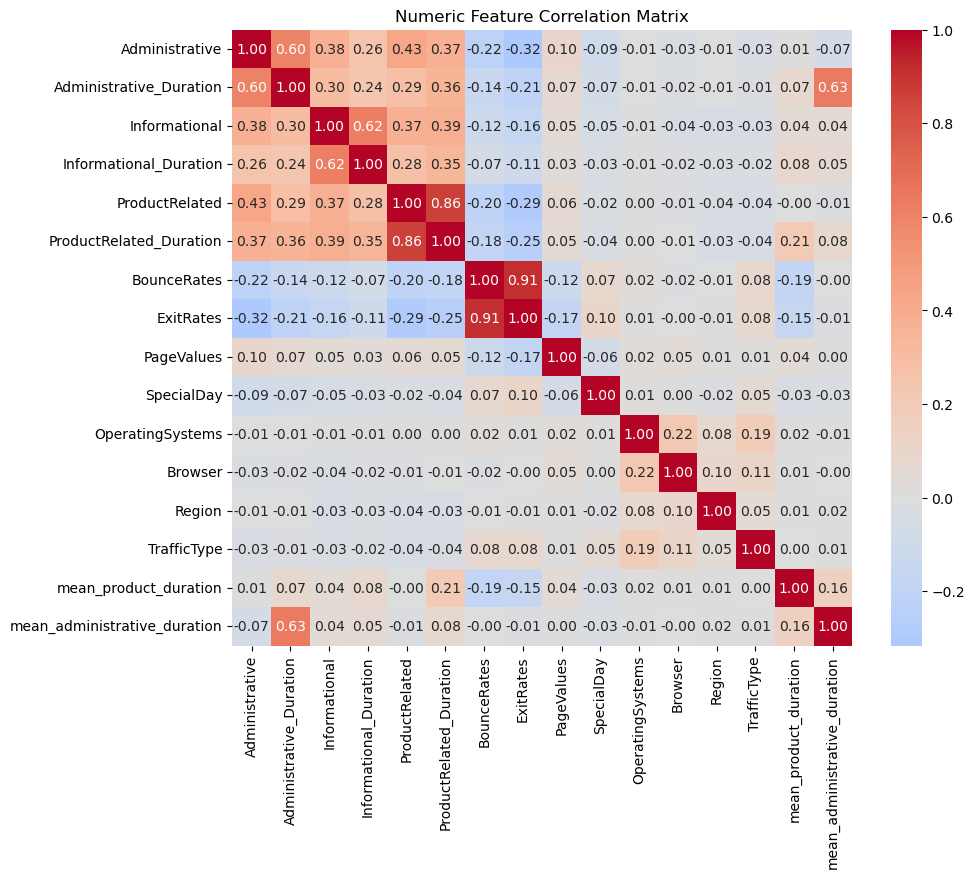

In [182]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df[numeric_cols].corr(method='pearson') 

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Numeric Feature Correlation Matrix')
plt.show()

Exit rates and bounce rates are almost perfectly correlated.

Strong correlations also exist for various pages 